In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset("tips")

In [3]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## 40. Загружаем датасет "tips"

In [4]:
# загружаем встроенный датасет про чаевые
tips = sns.load_dataset("tips")

# первые строки
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# типы данных по колонкам
tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

## 41. Чем больше счёт — тем больше чаевые?

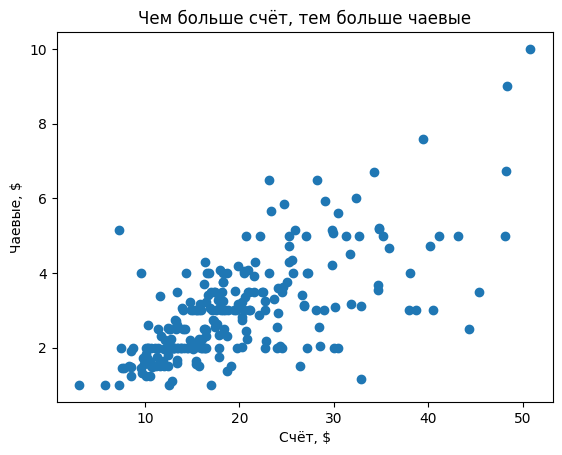

In [6]:
import matplotlib.pyplot as plt

# точечный график: счёт против чаевых
plt.scatter(tips["total_bill"], tips["tip"])
plt.title("Чем больше счёт, тем больше чаевые")
plt.xlabel("Счёт, $")
plt.ylabel("Чаевые, $")
plt.show()

## 42. Колонка tip_pct — процент чаевых от счёта

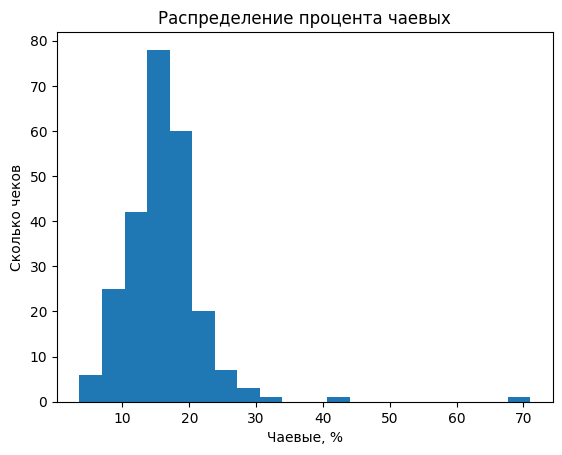

In [7]:
# процент чаевых от счёта
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100

# распределение процента чаевых
plt.hist(tips["tip_pct"], bins=20)
plt.title("Распределение процента чаевых")
plt.xlabel("Чаевые, %")
plt.ylabel("Сколько чеков")
plt.show()

## 43. Средний процент чаевых по дням недели

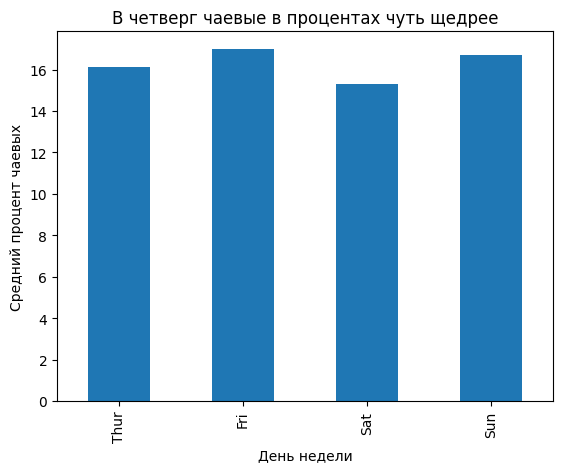

In [8]:
# средний процент чаевых по каждому дню
by_day = tips.groupby("day")["tip_pct"].mean()

by_day.plot(kind="bar")
plt.title("В четверг чаевые в процентах чуть щедрее")
plt.xlabel("День недели")
plt.ylabel("Средний процент чаевых")
plt.show()

## 44. Процент чаевых: курящие vs некурящие

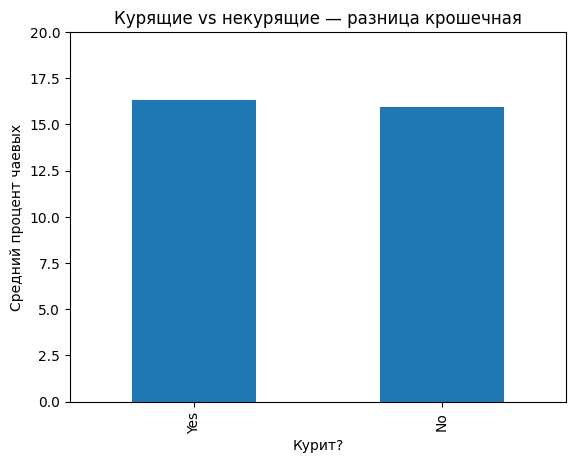

In [9]:
# средний процент чаевых для курящих и некурящих
by_smoker = tips.groupby("smoker")["tip_pct"].mean()

by_smoker.plot(kind="bar")
plt.title("Курящие vs некурящие — разница крошечная")
plt.xlabel("Курит?")
plt.ylabel("Средний процент чаевых")
plt.ylim(0, 20)  # честная ось: начинаем с нуля
plt.show()

## 45. Процент чаевых по размеру компании

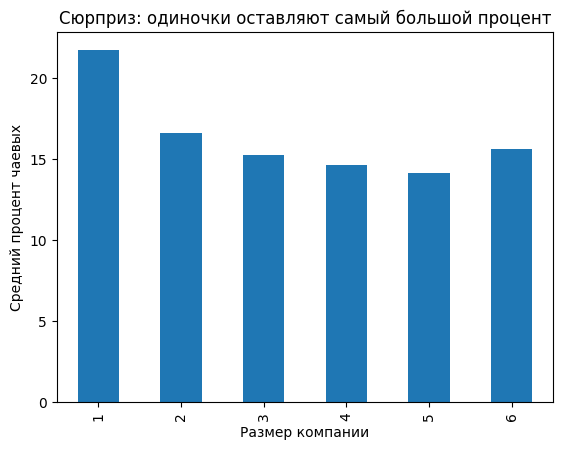

In [10]:
# средний процент чаевых по размеру компании
by_size = tips.groupby("size")["tip_pct"].mean()

by_size.plot(kind="bar")
plt.title("Сюрприз: одиночки оставляют самый большой процент")
plt.xlabel("Размер компании")
plt.ylabel("Средний процент чаевых")
plt.show()

## 46. Box plot процента чаевых: обед vs ужин

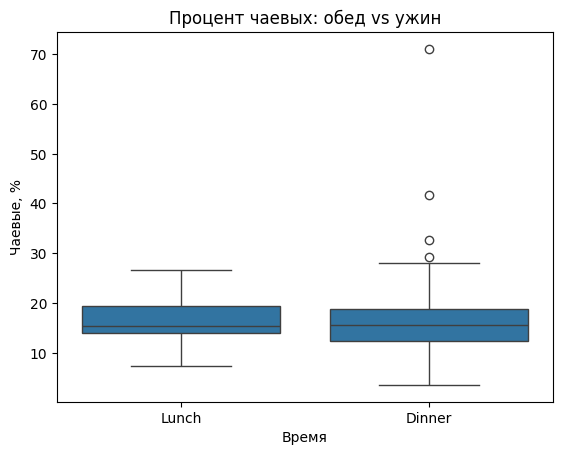

In [11]:
# box plot процента чаевых для обеда и ужина
sns.boxplot(data=tips, x="time", y="tip_pct")
plt.title("Процент чаевых: обед vs ужин")
plt.xlabel("Время")
plt.ylabel("Чаевые, %")
plt.show()

## 47. Выделяем одиночек, остальные — серым

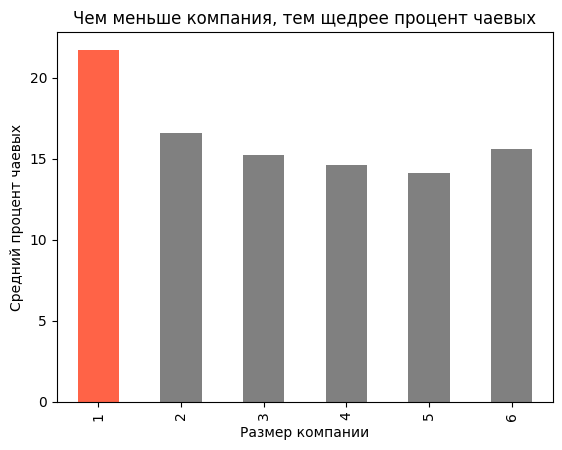

In [12]:
# красим столбик одиночек, остальные делаем серыми
colors = ["gray"] * len(by_size)
colors[0] = "tomato"  # размер компании = 1 (первый столбик)

by_size.plot(kind="bar", color=colors)
plt.title("Чем меньше компания, тем щедрее процент чаевых")
plt.xlabel("Размер компании")
plt.ylabel("Средний процент чаевых")
plt.show()

## 48. Правда ли большие компании щедрее? (по проценту)

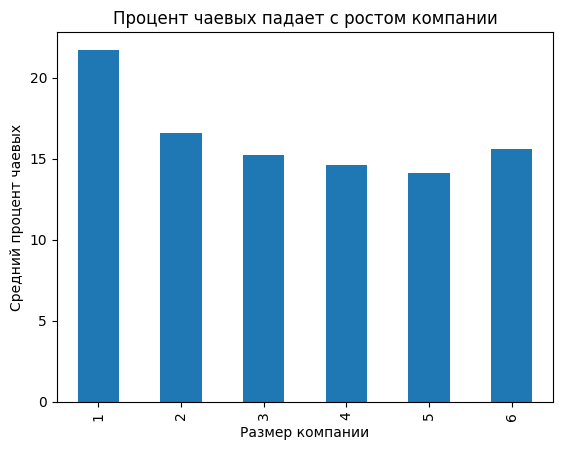

In [13]:
# график 1: средний ПРОЦЕНТ чаевых по размеру компании
by_size.plot(kind="bar")
plt.title("Процент чаевых падает с ростом компании")
plt.xlabel("Размер компании")
plt.ylabel("Средний процент чаевых")
plt.show()

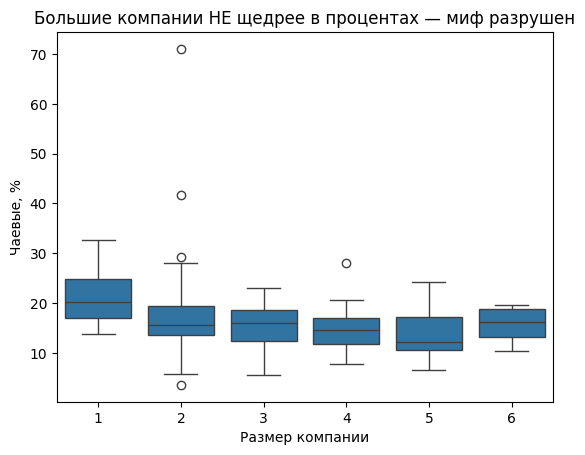

In [14]:
# график 2: каждый чек как точка — процент чаевых против размера компании
sns.boxplot(data=tips, x="size", y="tip_pct")
plt.title("Большие компании НЕ щедрее в процентах — миф разрушен")
plt.xlabel("Размер компании")
plt.ylabel("Чаевые, %")
plt.show()

## 49. История из 3 графиков: кто оставляет хорошие чаевые?

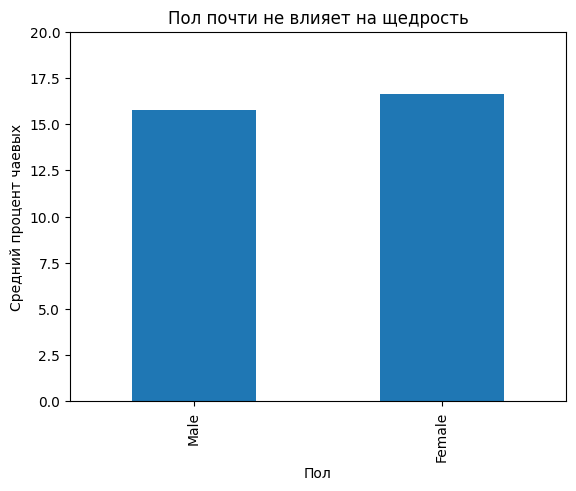

In [15]:
# график 1: пол почти не влияет на процент чаевых
tips.groupby("sex")["tip_pct"].mean().plot(kind="bar")
plt.title("Пол почти не влияет на щедрость")
plt.xlabel("Пол")
plt.ylabel("Средний процент чаевых")
plt.ylim(0, 20)
plt.show()

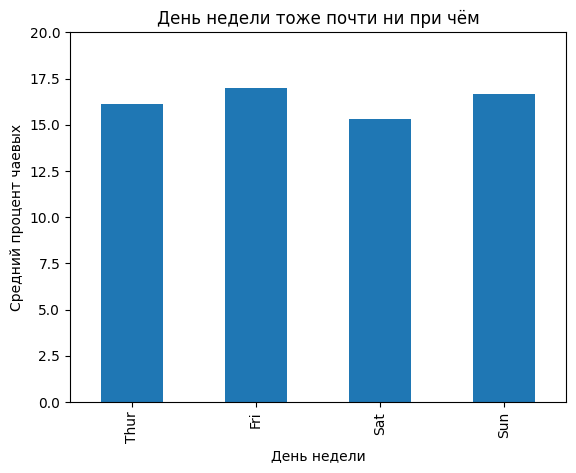

In [16]:
# график 2: день недели влияет слабо
tips.groupby("day")["tip_pct"].mean().plot(kind="bar")
plt.title("День недели тоже почти ни при чём")
plt.xlabel("День недели")
plt.ylabel("Средний процент чаевых")
plt.ylim(0, 20)
plt.show()

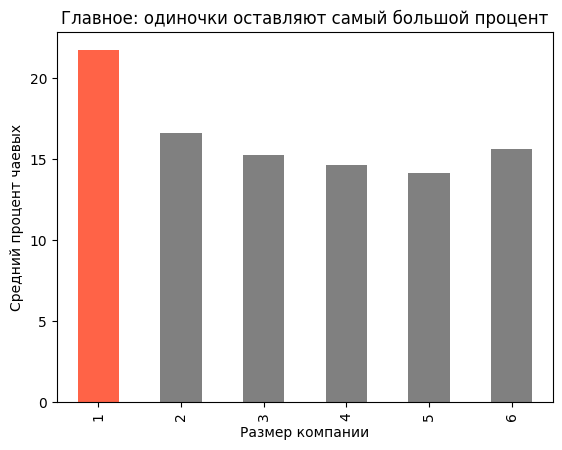

In [17]:
# график 3 (главный вывод): решает размер компании — одиночки щедрее всех
colors = ["gray"] * len(by_size)
colors[0] = "tomato"
by_size.plot(kind="bar", color=colors)
plt.title("Главное: одиночки оставляют самый большой процент")
plt.xlabel("Размер компании")
plt.ylabel("Средний процент чаевых")
plt.show()

## Курящие в долларах оставляют больше

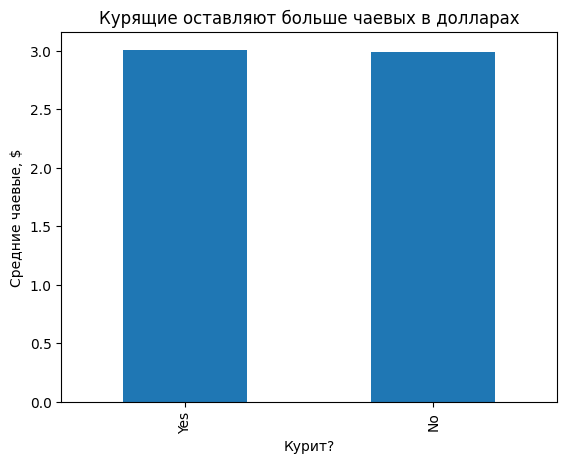

In [18]:
# средние чаевые в долларах для курящих и некурящих
tip_smoker = tips.groupby("smoker")["tip"].mean()

tip_smoker.plot(kind="bar")
plt.title("Курящие оставляют больше чаевых в долларах")
plt.xlabel("Курит?")
plt.ylabel("Средние чаевые, $")
plt.show()